Textile Production Data Analysis
COMP 3800 - Project #1

GitHub Repository:
https://github.com/credwine/textile-production-data-analysis

Data Source

This project uses the Textile Engineering Production Dataset from Kaggle. The dataset contains 1,000 production records and 11 variables related to machine operating conditions, production output, maintenance, alerts, and product defects.

Source: Kaggle - Textile Engineering Production Dataset

[Textile Dataset Kaggle](https://www.kaggle.com/datasets/zara2099/textile-engineering-production-dataset)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('/textile_engineering_dataset.csv')
df.head()

,machine_speed_rpm,temperature_c,humidity_percent,vibration_level,energy_usage_kwh,production_count,defect_count,hours_since_last_maintenance,maintenance_required,alert_triggered,defective_product
0,1549.671415,81.996777,46.284260,0.557313,116.713296,176,5,90,0,0,0
1,1486.173570,79.623168,32.640394,0.321413,124.241867,162,6,80,0,0,1
2,1564.768854,75.298152,43.952821,0.464037,100.132826,129,3,145,0,0,0
3,1652.302986,71.765316,34.439924,0.530111,99.682423,56,5,149,1,0,1
4,1476.584663,78.491117,62.329408,0.518383,92.229149,65,5,60,0,0,0


In [10]:
df.shape

(1000, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   machine_speed_rpm             1000 non-null   float64
 1   temperature_c                 1000 non-null   float64
 2   humidity_percent              1000 non-null   float64
 3   vibration_level               1000 non-null   float64
 4   energy_usage_kwh              1000 non-null   float64
 5   production_count              1000 non-null   int64  
 6   defect_count                  1000 non-null   int64  
 7   hours_since_last_maintenance  1000 non-null   int64  
 8   maintenance_required          1000 non-null   int64  
 9   alert_triggered               1000 non-null   int64  
 10  defective_product             1000 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 86.1 KB


In [13]:
df.describe()

,machine_speed_rpm,temperature_c,humidity_percent,vibration_level,energy_usage_kwh,production_count,defect_count,hours_since_last_maintenance,maintenance_required,alert_triggered,defective_product
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,1501.933206,75.354181,49.873938,0.499378,118.693507,127.096000,4.949000,97.60100,0.162000,0.086000,0.486000
std,97.921594,4.987272,11.612722,0.103664,19.741512,43.390846,2.174656,56.32753,0.368635,0.280504,0.500054
min,1175.873266,60.298057,30.000465,0.200886,56.465924,50.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1435.240969,71.968792,39.900196,0.428185,105.880129,88.000000,3.000000,50.00000,0.000000,0.000000,0.000000
50%,1502.530061,75.315386,50.020094,0.499864,119.315242,129.000000,5.000000,96.50000,0.000000,0.000000,0.000000
75%,1564.794388,78.644411,59.929076,0.568590,131.960395,164.250000,6.000000,145.00000,0.000000,0.000000,1.000000
max,1885.273149,90.965538,69.955704,0.892624,183.041135,199.000000,14.000000,199.00000,1.000000,1.000000,1.000000


Problem Statement

What operational and maintenance factors are associated with defective products in textile production?

Sub-questions

1. Is the defective product rate higher when maintenance is required?

2. How do machine speed, temperature, and vibration differ between defective and non-defective products?

3. Is the number of defects related to the amount of time since the machine's last maintenance?

Data Cleaning

In [16]:
df.isnull().sum()

,0
machine_speed_rpm,0
temperature_c,0
humidity_percent,0
vibration_level,0
energy_usage_kwh,0
production_count,0
defect_count,0
hours_since_last_maintenance,0
maintenance_required,0
alert_triggered,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dtypes

,0
machine_speed_rpm,float64
temperature_c,float64
humidity_percent,float64
vibration_level,float64
energy_usage_kwh,float64
production_count,int64
defect_count,int64
hours_since_last_maintenance,int64
maintenance_required,int64
alert_triggered,int64


In [21]:
for column in ['maintenance_required', 'alert_triggered', 'defective_product']:
    print(column, df[column].unique())

maintenance_required [0 1]
alert_triggered [0 1]
defective_product [0 1]


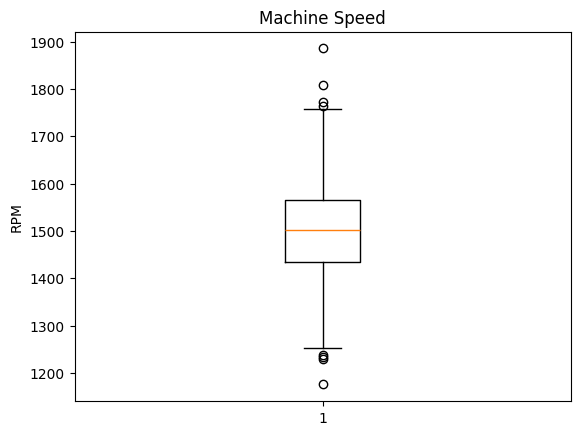

In [24]:
plt.boxplot(df['machine_speed_rpm'])
plt.title('Machine Speed')
plt.ylabel('RPM')
plt.show()

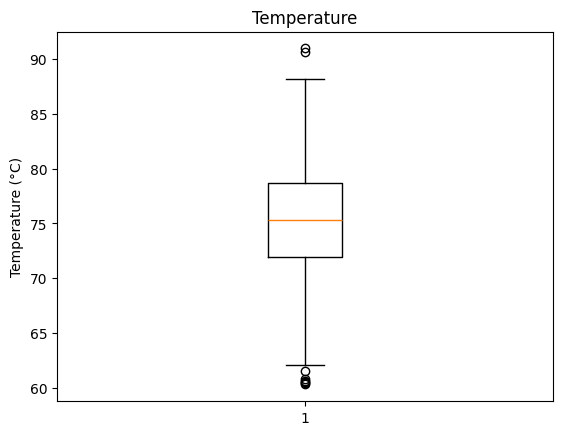

In [25]:
plt.boxplot(df['temperature_c'])
plt.title('Temperature')
plt.ylabel('Temperature (°C)')
plt.show()

Outlier Check

Boxplots were used to check the numerical data for possible outliers. Some unusually high and low values were observed. These values were kept because there was no evidence that they were incorrect or caused by data entry errors.

In [27]:
df.groupby('maintenance_required')['defective_product'].mean()

,defective_product
maintenance_required,
0,0.386635
1,1.000000


In [28]:
defect_rate = df.groupby('maintenance_required')['defective_product'].mean() * 100

defect_rate

,defective_product
maintenance_required,
0,38.663484
1,100.000000


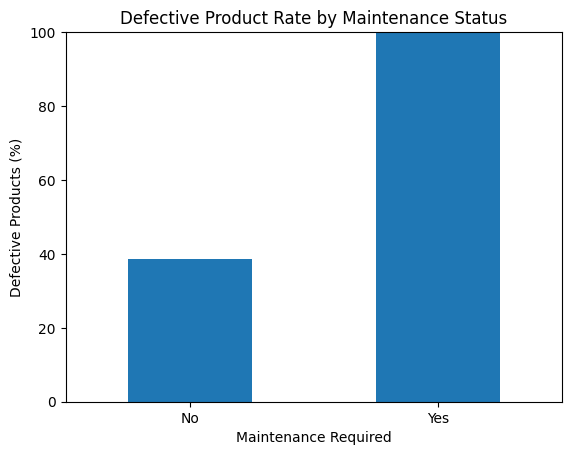

In [29]:
defect_rate.plot(kind='bar')

plt.title('Defective Product Rate by Maintenance Status')
plt.xlabel('Maintenance Required')
plt.ylabel('Defective Products (%)')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.ylim(0, 100)
plt.show()

Question 1 Interpretation

The defective product rate was about 38.7% when maintenance was not required and 100% when maintenance was required. This shows a strong association between maintenance status and defective products in this dataset. However, this analysis shows a relationship and does not prove that maintenance status caused the defects.

In [30]:
df.groupby('defective_product')[['machine_speed_rpm', 'temperature_c', 'vibration_level']].mean()

,machine_speed_rpm,temperature_c,vibration_level
defective_product,,,
0,1504.900647,75.068315,0.495471
1,1498.794800,75.656517,0.503511


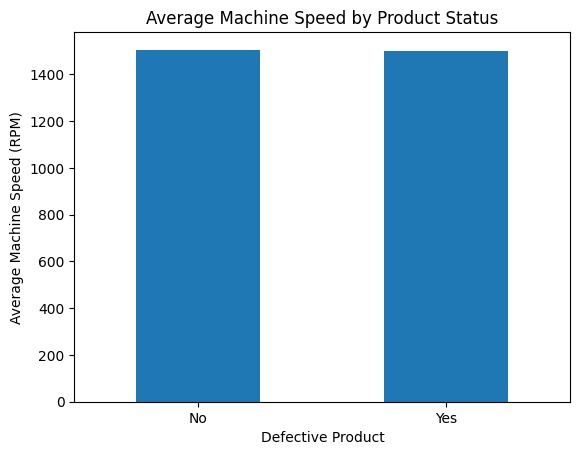

In [31]:
df.groupby('defective_product')['machine_speed_rpm'].mean().plot(kind='bar')

plt.title('Average Machine Speed by Product Status')
plt.xlabel('Defective Product')
plt.ylabel('Average Machine Speed (RPM)')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

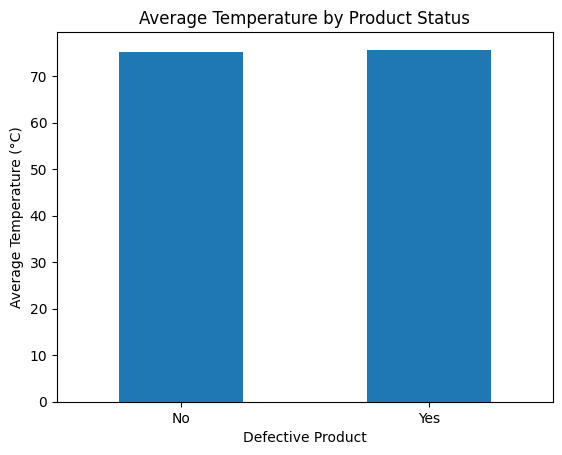

In [32]:
df.groupby('defective_product')['temperature_c'].mean().plot(kind='bar')

plt.title('Average Temperature by Product Status')
plt.xlabel('Defective Product')
plt.ylabel('Average Temperature (°C)')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

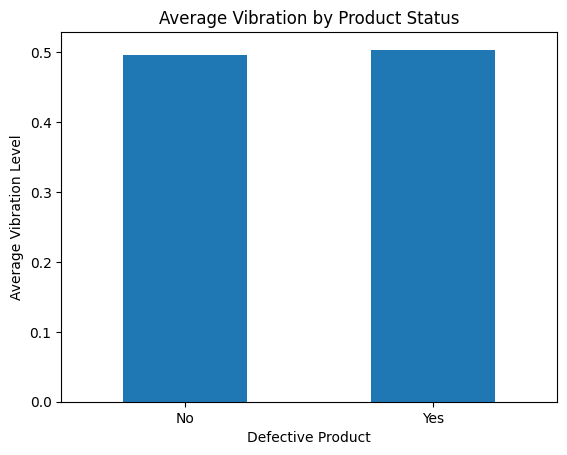

In [33]:
df.groupby('defective_product')['vibration_level'].mean().plot(kind='bar')

plt.title('Average Vibration by Product Status')
plt.xlabel('Defective Product')
plt.ylabel('Average Vibration Level')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

Question 2 Interpretation

The average machine speed, temperature, and vibration levels were similar for defective and non-defective products. Defective products had a slightly lower average machine speed and slightly higher average temperature and vibration, but the differences were small. Based on these averages, none of the three variables showed a large difference between defective and non-defective products.

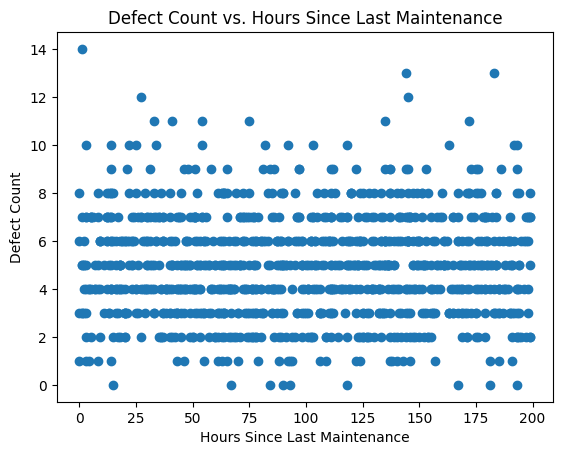

In [34]:
plt.scatter(df['hours_since_last_maintenance'], df['defect_count'])

plt.title('Defect Count vs. Hours Since Last Maintenance')
plt.xlabel('Hours Since Last Maintenance')
plt.ylabel('Defect Count')
plt.show()

In [35]:
df['hours_since_last_maintenance'].corr(df['defect_count'])

np.float64(-0.0009671366909161953)

Question 3 Interpretation

The scatter plot did not show a clear pattern between hours since last maintenance and defect count. The correlation was approximately -0.001, which is very close to zero. This indicates that there was little to no linear relationship between the two variables in this dataset.

Summary

This project looked at different operational and maintenance factors to see how they were associated with defective products in textile production. One of the biggest findings was the difference in defective product rates based on maintenance status. When maintenance was not required, about 38.7% of the products were defective. When maintenance was required, 100% were defective. This showed a strong association between maintenance status and defective products in this dataset.

I also compared machine speed, temperature, and vibration between defective and non-defective products. The averages were very similar between both groups, so there were no major differences found in these three areas. I also looked at the relationship between hours since last maintenance and defect count. The correlation was about -0.001, which showed little to no relationship between the two.

Overall, the strongest finding was the difference in defective product rates based on maintenance status. I did not find a clear relationship between defect count and time since maintenance or any major differences in machine speed, temperature, and vibration. In the future, I could look further into energy usage, production count, and alert status to see if they show any additional relationships with defective products.